In [2]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../data/parquet/events/source=DATABENTO/symbol=ONDS/date=2026-03-25/part.parquet")

In [3]:
df.head()

,order_id,session_id,symbol,source,side,event_type,event_seq,ts,price,size,remaining_size,reason
0,36931,1,ONDS,DATABENTO,ASK,ADD,0,1774425600234883829,14.44,2.0,2.0,NaN
1,56475,1,ONDS,DATABENTO,ASK,ADD,0,1774425600655578320,16.00,78.0,78.0,NaN
2,60647,1,ONDS,DATABENTO,BID,ADD,0,1774425600756680822,10.50,166.0,166.0,NaN
3,60747,1,ONDS,DATABENTO,ASK,ADD,0,1774425600761051451,15.20,35.0,35.0,NaN
4,61919,1,ONDS,DATABENTO,ASK,ADD,0,1774425600787670272,11.05,178.0,178.0,NaN


In [4]:
import matplotlib.pyplot as plt
from datetime import datetime

import pytz

In [8]:
tz = pytz.timezone("US/Eastern")

fill_time = df[df["event_type"]=="FILL"]["ts"].value_counts()
fill_time.sort_index(inplace=True)
ts = pd.to_datetime(fill_time.index, unit="ns", utc=True).tz_convert(tz)

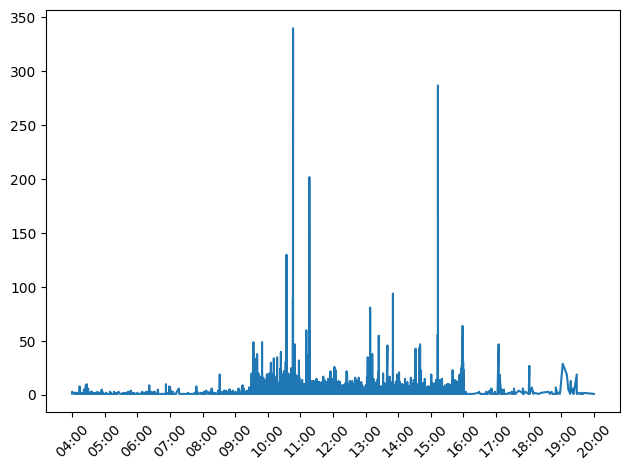

In [9]:
import matplotlib.dates as mdates


fig, ax = plt.subplots()
ax.plot(ts, fill_time.to_numpy())

# Show only hour:minute on x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=tz))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))  # tick every 1 hour

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
# Get fills and convert ts to EST
fills = df[df["event_type"] == "FILL"].copy()
fills["ts_dt"] = (
    pd.to_datetime(fills["ts"], unit="ns", utc=True)
    .astype("datetime64[us, UTC]")        # downcast ns → us while UTC
    .dt.tz_convert("America/New_York")          # then convert to EST
)

# Create 5-min interval bins
trade_date = fills["ts_dt"].dt.date.mode()[0]  # most common date in the data

bins = pd.date_range(
    start=f"{trade_date} 09:30",
    end=f"{trade_date} 16:00",
    freq="5min",
    tz="America/New_York"
)

# Cut into intervals and count
fills["interval"] = pd.cut(fills["ts_dt"], bins=bins, right=False)
counts = fills.groupby("interval", observed=True).size()
counts.min()

np.int64(71)

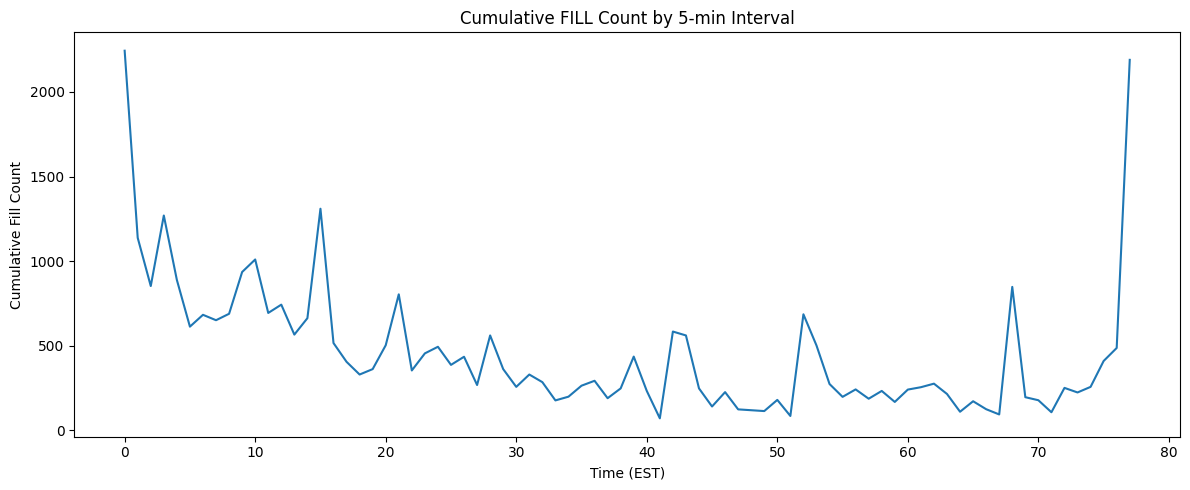

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(len(counts)),counts)

ax.set_title("Cumulative FILL Count by 5-min Interval")
ax.set_xlabel("Time (EST)")
ax.set_ylabel("Cumulative Fill Count")

plt.tight_layout()
plt.show()

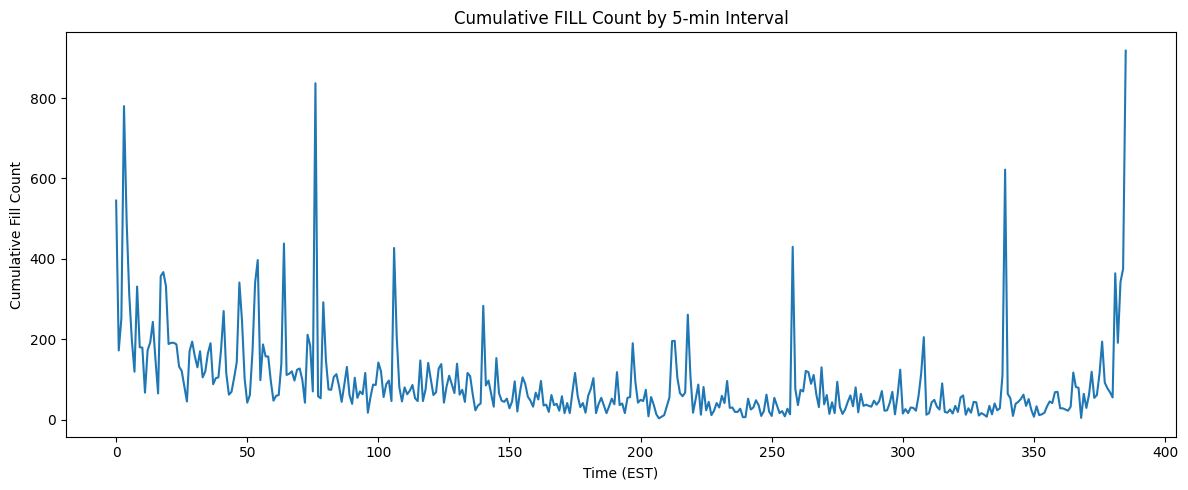

np.int64(3)

In [40]:
# Create 1-min interval bins
trade_date = fills["ts_dt"].dt.date.mode()[0]  # most common date in the data

bins = pd.date_range(
    start=f"{trade_date} 09:30",
    end=f"{trade_date} 16:00",
    freq="1min",
    tz="America/New_York"
)

# Cut into intervals and count
fills["interval"] = pd.cut(fills["ts_dt"], bins=bins, right=False)
counts = fills.groupby("interval", observed=True).size()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(len(counts)),counts)

ax.set_title("Cumulative FILL Count by 5-min Interval")
ax.set_xlabel("Time (EST)")
ax.set_ylabel("Cumulative Fill Count")

plt.tight_layout()
plt.show()

counts.min()

In [ ]:
# Convert ts column to datetime with EST timezone
df["ts_dt"] = pd.to_datetime(df["ts"], unit="ns", utc=True).dt.tz_convert("US/Eastern")

# Filter between 9:30 and 16:00
start = pd.Timestamp("09:30", tz="US/Eastern").time()
end   = pd.Timestamp("16:00", tz="US/Eastern").time()

df_filtered = df[df["ts_dt"].dt.time.between(start, end)]

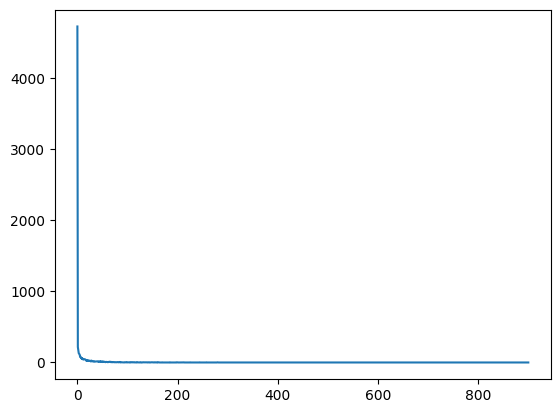

In [79]:
time_delta = ts.diff().total_seconds()
time_delta = time_delta.sort_values()
max_time_delta = time_delta.max()
ls = np.linspace(0, round(max_time_delta, -2),1000)
time_delta_distr = []
for i in range(1000):
    if i+1 == 1000:
        time_delta_distr.append(time_delta[time_delta>ls[i]].size)
    else:    
        time_delta_distr.append(time_delta[(time_delta<ls[i+1]) & (time_delta>ls[i])].size)
plt.subplot()
plt.plot(ls, time_delta_distr)